In [43]:
import os
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
TARGET_SR = 22050
# Từ điển ánh xạ mã số (vị trí thứ 3 trong tên file) sang tên cảm xúc
EMOTION_DICT = {
    '01': 'Bình thường', 
    '02': 'Bình tĩnh', 
    '03': 'Vui', 
    '04': 'Buồn',
    '05': 'Giận dữ', 
    '06': 'Sợ hãi', 
    '07': 'Ghê tởm', 
    '08': 'Bất ngờ'
}

DATA_PATH = "../data/RAVDESS/"
print("Đã load thư viện thành công!")


Đã load thư viện thành công!


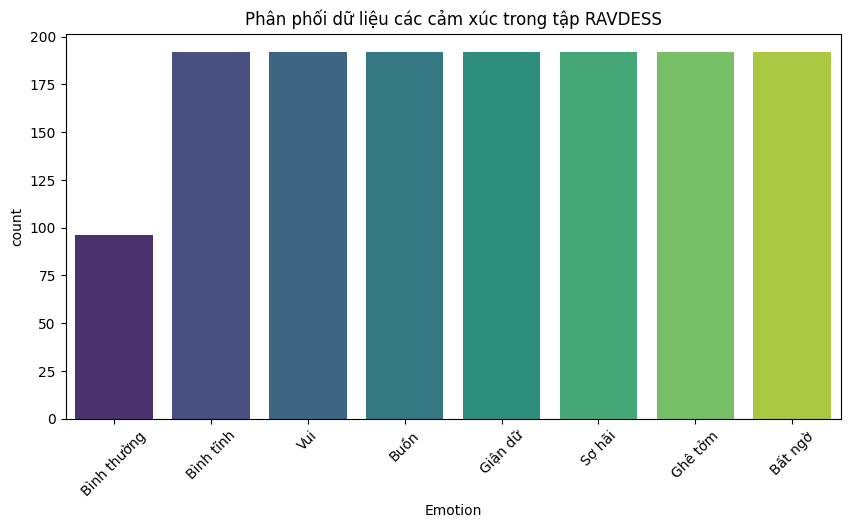

Emotion
Bình tĩnh      192
Vui            192
Buồn           192
Giận dữ        192
Sợ hãi         192
Ghê tởm        192
Bất ngờ        192
Bình thường     96
Name: count, dtype: int64


In [44]:
emotion_list = []

for actor_dir in os.listdir(DATA_PATH):
    actor_path = os.path.join(DATA_PATH, actor_dir)
    
    if os.path.isdir(actor_path):
        for file_name in os.listdir(actor_path):
            if file_name.endswith(".wav"):
                parts = file_name.split('-')
                emotion_code = parts[2]
                
                emotion_label = EMOTION_DICT[emotion_code]
                emotion_list.append(emotion_label)

df_emotions = pd.DataFrame(emotion_list, columns=['Emotion'])

plt.figure(figsize=(10, 5))
sns.countplot(data=df_emotions, x='Emotion', hue='Emotion', palette='viridis', legend=False)
plt.title('Phân phối dữ liệu các cảm xúc trong tập RAVDESS')
plt.xticks(rotation=45)
plt.show()

print(df_emotions['Emotion'].value_counts())


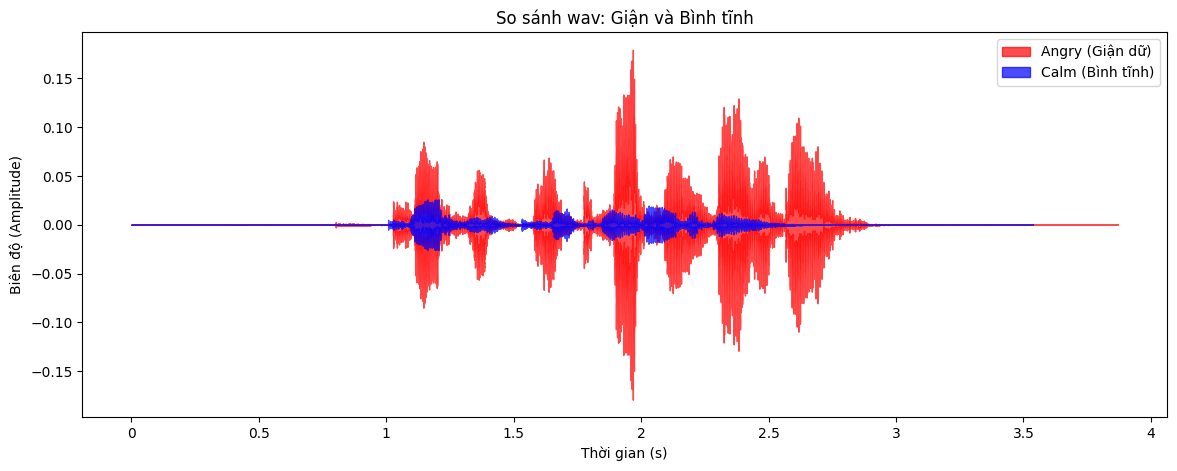

In [45]:
file_angry = "../data/RAVDESS/Actor_01/03-01-05-01-01-01-01.wav" # Angry (05)
file_calm = "../data/RAVDESS/Actor_01/03-01-02-01-01-01-01.wav"  # Calm (02)

y_angry, sr = librosa.load(file_angry, sr=TARGET_SR)
y_calm, _ = librosa.load(file_calm, sr=TARGET_SR)

plt.figure(figsize=(14, 5))

librosa.display.waveshow(y_angry, sr=sr, color="red", alpha=0.7, label="Angry (Giận dữ)")
librosa.display.waveshow(y_calm, sr=sr, color="blue", alpha=0.7, label="Calm (Bình tĩnh)")
plt.title("So sánh wav: Giận và Bình tĩnh")
plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ (Amplitude)")
plt.legend(loc="upper right") 
plt.show()


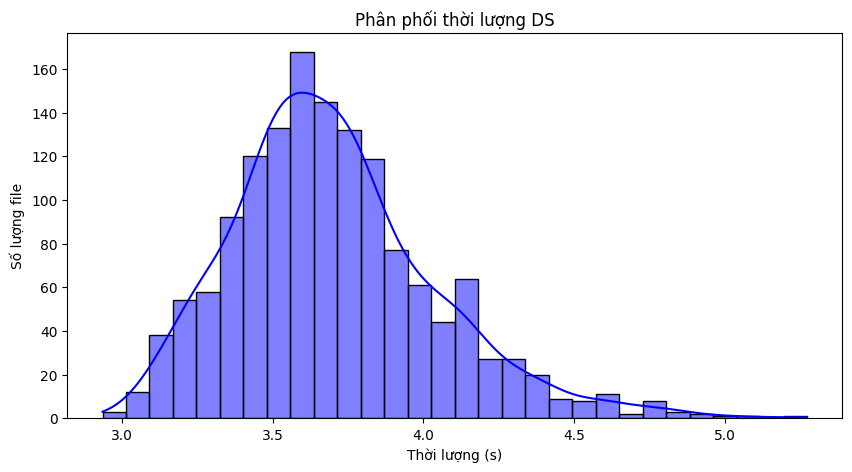

THỐNG KÊ ĐỘ DÀI (s)
Ngắn nhất (Min): 2.94 s
Dài nhất (Max): 5.27 s
Trung bình (Mean): 3.70 s
Trung vị (Median): 3.67 s
90% số file ngắn hơn: 4.14 s


In [46]:
durations = []

for actor_dir in os.listdir(DATA_PATH):
    actor_path = os.path.join(DATA_PATH, actor_dir)
    if os.path.isdir(actor_path):
        for file_name in os.listdir(actor_path):
            if file_name.endswith(".wav"):
                wav_path = os.path.join(actor_path, file_name)
                
                duration = librosa.get_duration(path=wav_path)
                durations.append(duration)

#Histogram
plt.figure(figsize=(10, 5))
sns.histplot(durations, bins=30, kde=True, color='blue')
plt.title("Phân phối thời lượng DS")
plt.xlabel("Thời lượng (s)")
plt.ylabel("Số lượng file")
plt.show()

df_dur = pd.Series(durations)
print("THỐNG KÊ ĐỘ DÀI (s)")
print(f"Ngắn nhất (Min): {df_dur.min():.2f} s")
print(f"Dài nhất (Max): {df_dur.max():.2f} s")
print(f"Trung bình (Mean): {df_dur.mean():.2f} s")
print(f"Trung vị (Median): {df_dur.median():.2f} s")
print(f"90% số file ngắn hơn: {df_dur.quantile(0.90):.2f} s")



THỐNG KÊ ĐỘ DÀI SAU KHI CẮT KHOẢNG LẶNG
Tổng số file: 1440
- Ngắn nhất (Min): 0.84 s
- Dài nhất (Max): 3.39 s
- Trung bình (Mean): 1.70 s
- Số lượng file ruột <=3 s: 1435 file (Chiếm 99.65%)


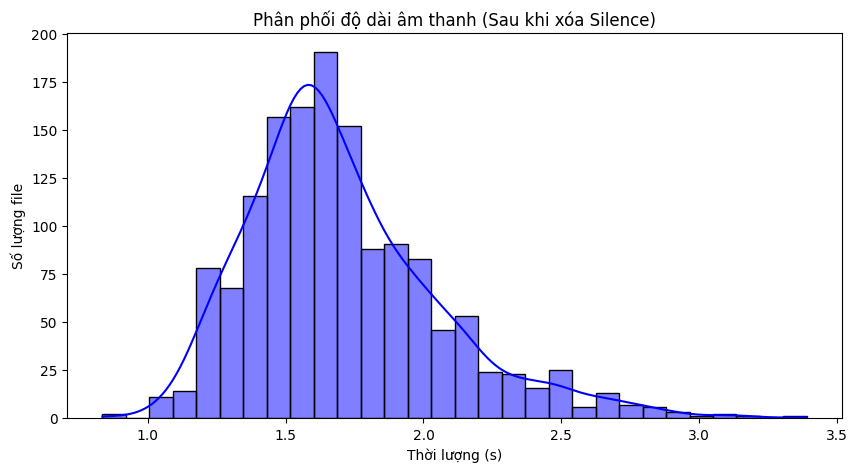

In [47]:

trimmed_durations = []
for actor_dir in os.listdir(DATA_PATH):
    actor_path = os.path.join(DATA_PATH, actor_dir)
    if os.path.isdir(actor_path):
        for file_name in os.listdir(actor_path):
            if file_name.endswith(".wav"):
                wav_path = os.path.join(actor_path, file_name)
                
                y, sr = librosa.load(wav_path, sr=TARGET_SR)
                y_trimmed, index = librosa.effects.trim(y, top_db=20)
                true_duration = len(y_trimmed) / sr
                trimmed_durations.append(true_duration)

df_trimmed = pd.Series(trimmed_durations)
total_files = len(df_trimmed)
under_3s = (df_trimmed <= 3.0).sum()
percent_under_3s = (under_3s / total_files) * 100

print("\nTHỐNG KÊ ĐỘ DÀI SAU KHI CẮT KHOẢNG LẶNG")
print(f"Tổng số file: {total_files}")
print(f"- Ngắn nhất (Min): {df_trimmed.min():.2f} s")
print(f"- Dài nhất (Max): {df_trimmed.max():.2f} s")
print(f"- Trung bình (Mean): {df_trimmed.mean():.2f} s")
print(f"- Số lượng file ruột <=3 s: {under_3s} file (Chiếm {percent_under_3s:.2f}%)")

plt.figure(figsize=(10, 5))
sns.histplot(trimmed_durations, bins=30, kde=True, color='blue')
plt.title('Phân phối độ dài âm thanh (Sau khi xóa Silence)')
plt.xlabel("Thời lượng (s)")
plt.ylabel("Số lượng file")
plt.show()
